## Preparation

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import pandas as pd
import pickle
import sys
import math
import random
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from sklearn.metrics import silhouette_score

In [4]:
!{sys.executable} -m pip install -q "pyarrow>=13.0.0"

df = pd.read_pickle(
    r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\harmonized_data_2292026_rightSMILES.pkl"
)

In [3]:
import re
other_cols = [
    col for col in df.columns 
    if not col.startswith('Bit_') and not re.match(r'.* \(\d+\)', col)
]

print(f"Gefundene Spalten ({len(other_cols)}):")
for col in other_cols:
    print(col)

Gefundene Spalten (20):
ModelID
SMILES
SequencingID
SANGER_MODEL_ID
CANCER_TYPE
DRUG_ID
DRUG_NAME
LN_IC50
Z_SCORE
RMSE
AUC
MorganFP
Donor
Acceptor
Aromatic
Hydrophobe
LumpedHydrophobe
PosIonizable
NegIonizable
ZnBinder


In [4]:
print(df['CANCER_TYPE'].unique())

<StringArray>
[                 'Ovarian Carcinoma',             'Acute Myeloid Leukemia',
               'Colorectal Carcinoma',                           'Melanoma',
      'Non-Small Cell Lung Carcinoma',                  'Bladder Carcinoma',
                   'Breast Carcinoma',           'B-Lymphoblastic Leukemia',
               'Pancreatic Carcinoma',                'Plasma Cell Myeloma',
                             'Glioma',                   'Kidney Carcinoma',
                    'Ewing's Sarcoma',      'T-Cell Non-Hodgkin's Lymphoma',
                     'Other Sarcomas',                'Other Solid Cancers',
      'B-Cell Non-Hodgkin's Lymphoma',            'Thyroid Gland Carcinoma',
       'Chronic Myelogenous Leukemia',                       'Glioblastoma',
                      'Neuroblastoma',                       'Osteosarcoma',
                 'Prostate Carcinoma',                       'Mesothelioma',
                   'Rhabdomyosarcoma',           'T-Lymphoblas

## Training data

In [12]:
# training data group split in train val
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe', 'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem = df[pharmacophores + mfp_cols]
y = df[target].values.astype('float32')

# split data into train and test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=6726)
idx_train_val, idx_test = next(gss_test.split(X_genomic, y, groups=df['DRUG_ID']))

# separate validation set from training set
groups_train_val = df['DRUG_ID'].iloc[idx_train_val]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
idx_train, idx_val = next(gss_val.split(X_genomic[idx_train_val], y[idx_train_val], groups=groups_train_val))

idx_train = idx_train_val[idx_train]
idx_val = idx_train_val[idx_val]

preprocessor = ColumnTransformer(
    transformers=[
        ('pharmacophore', StandardScaler(), pharmacophores),
        #('mfp', PCA(n_components=50, random_state=42), mfp_cols)
        ('mfp', 'passthrough', mfp_cols)
    ],
    remainder='drop'
)
gene_scaler = StandardScaler()

X_genomic_train = gene_scaler.fit_transform(X_genomic[idx_train])
X_chem_train = preprocessor.fit_transform(X_chem.iloc[idx_train])

X_genomic_val = gene_scaler.transform(X_genomic[idx_val])
X_chem_val = preprocessor.transform(X_chem.iloc[idx_val])

X_genomic_test = gene_scaler.transform(X_genomic[idx_test])
X_chem_test = preprocessor.transform(X_chem.iloc[idx_test])

# scale IC50 values
#scaler = StandardScaler()
y_train = y[idx_train]#scaler.fit_transform(y[idx_train].reshape(-1, 1)).flatten()
y_val = y[idx_val]#scaler.transform(y[idx_val].reshape(-1, 1)).flatten()
y_test = y[idx_test]#scaler.transform(y[idx_test].reshape(-1, 1)).flatten()

In [13]:
def make_loaders(batch_size=128, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        DrugResponseDataset(X_genomic_train, X_chem_train, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    val_loader = DataLoader(
        DrugResponseDataset(X_genomic_val, X_chem_val, y_val),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        DrugResponseDataset(X_genomic_test, X_chem_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader

class DrugResponseDataset(Dataset):
    def __init__(self, X_gen, X_ch, labels):
        self.X_genomic = torch.tensor(X_gen, dtype=torch.float32)
        self.X_chem = torch.tensor(X_ch if isinstance(X_ch, np.ndarray) else X_ch.values, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_genomic[idx], self.X_chem[idx], self.y[idx]

## New: create tokens in meaningful way

Gene Tokens: differentiate anhand von similar expression profiles

In [7]:
# compute correlation matrix for genomic features
gene_corr = np.corrcoef(X_genomic.T)

dist_matrix = np.clip(1.0 - gene_corr, 0, 2)
np.fill_diagonal(dist_matrix, 0)

# Ward Linkage
condensed_dist = pdist(dist_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# automatic finding of the best token number (e.g., search from k=2 to 50)
candidate_k = range(2, 51)
scores = []

for k in candidate_k:
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust') - 1
    # Silhouette Score auf Basis der vorberechneten Distanzmatrix
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    scores.append(score)

# Optimales k auswählen
optimal_k = candidate_k[np.argmax(scores)]
print(f"Optimal gefundene Token-Anzahl: {optimal_k} (Silhouette Score: {max(scores):.4f})")

# 5. Finale Clusterzuweisung
gene_clusters = fcluster(linkage_matrix, t=optimal_k, criterion='maxclust') - 1
gene_token_indices = [np.where(gene_clusters == i)[0] for i in range(optimal_k)]

for i, indices in enumerate(gene_token_indices):
    print(f"Gene Token {i}: {len(indices)} genes assigned")

Optimal gefundene Token-Anzahl: 2 (Silhouette Score: 0.1371)
Gene Token 0: 377 genes assigned
Gene Token 1: 601 genes assigned


Another way to create gene tokens: Assign each gene to a pathway

In [8]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

gene_feature_names = df.filter(regex=r'.* \(.*\)').columns.tolist()

# correlation matrix for genomic features
X_genomic = df.filter(regex=r'.* \(.*\)').values.astype('float32')
gene_corr = np.corrcoef(X_genomic.T)  # (978, 978)

# distance matrix and ward-linkage
dist_matrix = np.clip(1.0 - gene_corr, 0, 2)
np.fill_diagonal(dist_matrix, 0)
condensed_dist = pdist(dist_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# cut into 8 clusters (tokens)
num_tokens = 8
gene_clusters = fcluster(linkage_matrix, t=num_tokens, criterion='maxclust') - 1

gene_token_indices = [np.where(gene_clusters == i)[0] for i in range(num_tokens)]

for i, indices in enumerate(gene_token_indices):
    print(f"Gene Token {i}: {len(indices)} genes assigned")

Gene Token 0: 185 genes assigned
Gene Token 1: 65 genes assigned
Gene Token 2: 127 genes assigned
Gene Token 3: 112 genes assigned
Gene Token 4: 85 genes assigned
Gene Token 5: 77 genes assigned
Gene Token 6: 150 genes assigned
Gene Token 7: 177 genes assigned


Third way to create gene tokens.
- Take cancer types and create one token for each cancer type
- A gene is not simply assigned to the cancer type in which it is expressed at the absolute highest level (since housekeeping genes would otherwise be highly expressed everywhere), but rather to the cancer type for which it is most specifically upregulated compared to all other cancer types.
- Each gene is assigned precisely to the cancer type for which its $Z$-score reaches its maximum value

In [14]:
gene_cols = df.filter(regex=r'.* \(.*\)').columns.tolist()
X_genes = df[gene_cols].values
cancer_types = df['CANCER_TYPE'].values
unique_cancer_types = df['CANCER_TYPE'].unique()

mean_expr = np.array([X_genes[cancer_types == ct].mean(axis=0) for ct in unique_cancer_types])
mean_expr_z = (mean_expr - mean_expr.mean(axis=0)) / (mean_expr.std(axis=0) + 1e-8)
gene_assignments = np.argmax(mean_expr_z, axis=0)

gene_token_indices = []
active_labels = []

for ct_idx, ct_name in enumerate(unique_cancer_types):
    idx = np.where(gene_assignments == ct_idx)[0]
    if len(idx) > 0:
        gene_token_indices.append(idx)
        active_labels.append(ct_name)
        print(f"Token {len(gene_token_indices)-1} ({ct_name}): {len(idx)} genes")

Token 0 (Acute Myeloid Leukemia): 15 genes
Token 1 (Colorectal Carcinoma): 10 genes
Token 2 (Melanoma): 53 genes
Token 3 (Bladder Carcinoma): 4 genes
Token 4 (Breast Carcinoma): 8 genes
Token 5 (B-Lymphoblastic Leukemia): 26 genes
Token 6 (Pancreatic Carcinoma): 3 genes
Token 7 (Plasma Cell Myeloma): 21 genes
Token 8 (Glioma): 52 genes
Token 9 (Kidney Carcinoma): 20 genes
Token 10 (Ewing's Sarcoma): 44 genes
Token 11 (T-Cell Non-Hodgkin's Lymphoma): 28 genes
Token 12 (Other Sarcomas): 4 genes
Token 13 (B-Cell Non-Hodgkin's Lymphoma): 4 genes
Token 14 (Thyroid Gland Carcinoma): 3 genes
Token 15 (Chronic Myelogenous Leukemia): 13 genes
Token 16 (Glioblastoma): 8 genes
Token 17 (Neuroblastoma): 33 genes
Token 18 (Osteosarcoma): 16 genes
Token 19 (Prostate Carcinoma): 9 genes
Token 20 (Mesothelioma): 33 genes
Token 21 (Rhabdomyosarcoma): 22 genes
Token 22 (T-Lymphoblastic Leukemia): 100 genes
Token 23 (Small Cell Lung Carcinoma): 47 genes
Token 24 (Gastric Carcinoma): 3 genes
Token 25 (Bur

Drug tokens:

In [15]:
import numpy as np
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

# 1. Select chemical columns
chem_cols = pharmacophores + mfp_cols

# 2. Extract unique drug feature matrix
unique_drugs_df = df.drop_duplicates(subset=['DRUG_ID'])[chem_cols]
chem_values = unique_drugs_df.values.astype(np.float64)  # shape: (n_drugs, 1032)

# 3. Compute Pearson correlation with variance check
# Identify constant columns (zero variance)
std_devs = np.std(chem_values, axis=0)
valid_mask = std_devs > 1e-8

# Compute correlation matrix
chem_corr = np.zeros((len(chem_cols), len(chem_cols)), dtype=np.float64)

# Correlate non-constant features
chem_corr_valid = np.corrcoef(chem_values[:, valid_mask].T)

# Place valid correlations into full matrix
valid_indices = np.where(valid_mask)[0]
for i_idx, i in enumerate(valid_indices):
    for j_idx, j in enumerate(valid_indices):
        chem_corr[i, j] = chem_corr_valid[i_idx, j_idx]

# 4. Convert correlation to distance: dist = 1 - r
dist_matrix_chem = 1.0 - chem_corr

# Handle any remaining NaN/Inf values by setting distance to 1.0 (uncorrelated)
dist_matrix_chem = np.nan_to_num(dist_matrix_chem, nan=1.0, posinf=1.0, neginf=1.0)
dist_matrix_chem = np.clip(dist_matrix_chem, 0.0, 2.0)
np.fill_diagonal(dist_matrix_chem, 0.0)

# 5. Hierarchical clustering on condensed distance matrix
condensed_dist = pdist(dist_matrix_chem)
linkage_chem = linkage(condensed_dist, method='ward')

# 6. Extract cluster labels for 5 tokens
num_drug_tokens = 8
chem_cluster_labels = fcluster(linkage_chem, t=num_drug_tokens, criterion='maxclust') - 1

# 7. Form index arrays for each token
chem_token_indices = [
    np.where(chem_cluster_labels == i)[0] for i in range(num_drug_tokens)
]

for i, idx in enumerate(chem_token_indices):
    print(f"Drug Token {i}: {len(idx)} features assigned")

Drug Token 0: 49 features assigned
Drug Token 1: 76 features assigned
Drug Token 2: 62 features assigned
Drug Token 3: 125 features assigned
Drug Token 4: 75 features assigned
Drug Token 5: 532 features assigned
Drug Token 6: 65 features assigned
Drug Token 7: 48 features assigned


### Test

In [16]:
import torch
import torch.nn as nn

class ModularTokenEncoder(nn.Module):
    """Encodes disjoint subsets of feature columns into separate functional tokens."""
    def __init__(self, feature_subsets_indices, hidden_dim=64, dropout=0.3):
        super().__init__()
        # Register token index buffers
        self.subset_indices = [
            torch.tensor(idx, dtype=torch.long) for idx in feature_subsets_indices
        ]
        
        # Dedicated projection per functional feature partition
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Linear(len(idx), hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for idx in feature_subsets_indices
        ])

    def forward(self, x):
        # x shape: (Batch_Size, total_features)
        token_list = []
        for idx, proj in zip(self.subset_indices, self.projections):
            sub_x = x[:, idx.to(x.device)]
            token = proj(sub_x) # (B, hidden_dim)
            token_list.append(token)
        return torch.stack(token_list, dim=1) # (B, num_tokens, hidden_dim)


class GroundedCrossAttentionModel(nn.Module):
    def __init__(
        self,
        gene_token_indices,
        chem_token_indices,
        hidden_dim=64,
        num_heads=4,
        dropout=0.3
    ):
        super().__init__()
        self.num_gene_tokens = len(gene_token_indices)
        self.num_drug_tokens = len(chem_token_indices)
        self.hidden_dim = hidden_dim

        self.input_dropout_gene = nn.Dropout(0.2)
        self.input_dropout_chem = nn.Dropout(0.3)

        # 1. Modular Token Encoders (Option B)
        self.gene_encoder = ModularTokenEncoder(gene_token_indices, hidden_dim, dropout)
        self.drug_encoder = ModularTokenEncoder(chem_token_indices, hidden_dim, dropout)

        # 2. Positional / Identity Embeddings per token
        self.gene_pos = nn.Parameter(torch.randn(1, self.num_gene_tokens, hidden_dim) * 0.02)
        self.drug_pos = nn.Parameter(torch.randn(1, self.num_drug_tokens, hidden_dim) * 0.02)

        # 3. Cross-Attention Modules
        self.cross_attn_gene_to_drug = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.cross_attn_drug_to_gene = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )

        self.norm_gene = nn.LayerNorm(hidden_dim)
        self.norm_drug = nn.LayerNorm(hidden_dim)

        # 4. Regressor Head on Pooled Multimodal Context
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_gene, x_drug):
        batch_size = x_gene.size(0)
        x_gene = self.input_dropout_gene(x_gene)
        x_drug = self.input_dropout_chem(x_drug)

        # (B, num_tokens, hidden_dim)
        gene_tokens = self.gene_encoder(x_gene) + self.gene_pos
        drug_tokens = self.drug_encoder(x_drug) + self.drug_pos

        # Cross-Attention
        gene_attn_out, gene_attn_weights = self.cross_attn_gene_to_drug(
            query=gene_tokens, key=drug_tokens, value=drug_tokens
        )
        drug_attn_out, drug_attn_weights = self.cross_attn_drug_to_gene(
            query=drug_tokens, key=gene_tokens, value=gene_tokens
        )

        # Store weights for post-hoc interpretability
        self.last_attn_weights = {
            "gene_to_drug": gene_attn_weights.detach().cpu().numpy(),
            "drug_to_gene": drug_attn_weights.detach().cpu().numpy()
        }

        # Residual Context
        gene_context = self.norm_gene(gene_tokens + gene_attn_out)
        drug_context = self.norm_drug(drug_tokens + drug_attn_out)

        # Pool across token dimensions to prevent shortcut collapse
        gene_pooled = gene_context.mean(dim=1) # (B, hidden_dim)
        drug_pooled = drug_context.mean(dim=1) # (B, hidden_dim)

        fused = torch.cat([gene_pooled, drug_pooled], dim=1) # (B, hidden_dim * 2)
        pred = self.regressor(fused)
        return pred.squeeze(1)

## Configuration

In [17]:
target = 'LN_IC50'
pharmacophores = ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'LumpedHydrophobe',
                   'PosIonizable', 'NegIonizable', 'ZnBinder']
mfp_cols = [col for col in df.columns if col.startswith('Bit_')]

X_genomic_raw = df.filter(regex=r'.* \(.*\)').values.astype('float32')
X_chem_raw = df[pharmacophores + mfp_cols]
y_raw = df[target].values.astype('float32')
drug_groups = df['DRUG_ID'].values

seeds = [42, 101, 1337, 9999]  # 5 different seeds , 6726
hidden_dim = 64
dropout = 0.3
lr = 1e-3
weight_decay = 1e-3
epochs = 25
patience = 6
batch_size = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# multiple seeds for robust evaluation
seed_results = []

for run_idx, seed in enumerate(seeds):
    print(f"\n==========================================")
    print(f"Seed {run_idx + 1}/{len(seeds)} (Seed-value: {seed})")
    print(f"==========================================")
    
    set_seed(seed)

    # data splits by DRUG_ID
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=18092026)
    idx_train_val, idx_test = next(gss_test.split(X_genomic_raw, y_raw, groups=drug_groups))

    groups_train_val = drug_groups[idx_train_val]
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=18092026)
    idx_tr_rel, idx_val_rel = next(
        gss_val.split(X_genomic_raw[idx_train_val], y_raw[idx_train_val], groups=groups_train_val)
    )
    idx_train = idx_train_val[idx_tr_rel]
    idx_val = idx_train_val[idx_val_rel]

    # scaling
    preprocessor = ColumnTransformer(
        transformers=[
            ('pharmacophore', StandardScaler(), pharmacophores),
            ('mfp', 'passthrough', mfp_cols)
        ],
        remainder='drop'
    )
    gene_scaler = StandardScaler()

    X_gen_train = gene_scaler.fit_transform(X_genomic_raw[idx_train])
    X_chem_train = preprocessor.fit_transform(X_chem_raw.iloc[idx_train])

    X_gen_val = gene_scaler.transform(X_genomic_raw[idx_val])
    X_chem_val = preprocessor.transform(X_chem_raw.iloc[idx_val])

    X_gen_test = gene_scaler.transform(X_genomic_raw[idx_test])
    X_chem_test = preprocessor.transform(X_chem_raw.iloc[idx_test])

    y_train, y_val, y_test = y_raw[idx_train], y_raw[idx_val], y_raw[idx_test]

    # DataLoader
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        DrugResponseDataset(X_gen_train, X_chem_train, y_train),
        batch_size=batch_size, shuffle=True, drop_last=True, generator=g
    )
    val_loader = DataLoader(
        DrugResponseDataset(X_gen_val, X_chem_val, y_val),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        DrugResponseDataset(X_gen_test, X_chem_test, y_test),
        batch_size=batch_size, shuffle=False
    )

    # initialize model, criterion, optimizer, scheduler
    model = GroundedCrossAttentionModel(
        gene_token_indices=gene_token_indices,
        chem_token_indices=chem_token_indices,
        hidden_dim=hidden_dim,
        num_heads=4,
        dropout=dropout
    ).to(device)

    criterion = nn.MSELoss()
    #optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=patience)

    best_val_rmse = float("inf")
    best_epoch = -1
    model_checkpoint_path = f"best_model_seed_{seed}.pt"

    # training
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for b_genes, b_chem, b_y in train_loader:
            b_genes, b_chem, b_y = b_genes.to(device), b_chem.to(device), b_y.to(device).view(-1)

            optimizer.zero_grad()
            preds = model(b_genes, b_chem).view(-1)
            loss = criterion(preds, b_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * b_genes.size(0)

        # validation
        model.eval()
        val_preds, val_targets = [], []
        val_loss = 0.0
        with torch.no_grad():
            for b_genes, b_chem, b_y in val_loader:
                b_genes, b_chem, b_y = b_genes.to(device), b_chem.to(device), b_y.to(device).view(-1)
                preds = model(b_genes, b_chem).view(-1)
                loss = criterion(preds, b_y)
                val_loss += loss.item() * b_genes.size(0)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(b_y.cpu().numpy())

        total_val_loss = val_loss / len(val_loader.dataset)
        val_rmse = root_mean_squared_error(val_targets, val_preds)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            torch.save(model.state_dict(), model_checkpoint_path)

        scheduler.step(total_val_loss)

    # 6. evaluation with best checkpoint for this seed
    model.load_state_dict(torch.load(model_checkpoint_path, weights_only=True))
    model.eval()

    test_preds, test_targets = [], []
    with torch.no_grad():
        for b_genes, b_chem, b_y in test_loader:
            b_genes, b_chem = b_genes.to(device), b_chem.to(device)
            preds = model(b_genes, b_chem).view(-1)
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(b_y.numpy())

    test_rmse = root_mean_squared_error(test_targets, test_preds)
    test_r2 = r2_score(test_targets, test_preds)

    print(f"--> Result Seed {seed}: Best Epoch: {best_epoch:02d} | Val RMSE: {best_val_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

    seed_results.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_rmse": best_val_rmse,
        "test_rmse": test_rmse,
        "test_r2": test_r2
    })

# summary
df_results = pd.DataFrame(seed_results)

print("\n" + "="*50)
print("OVERALL ANALYSIS OF ALL SEEDS")
print("="*50)
print(df_results.to_string(index=False))

print("\n--- Aggregated metrics (mean ± standard deviation) ---")
print(f"Test RMSE: {df_results['test_rmse'].mean():.4f} ± {df_results['test_rmse'].std():.4f}")
print(f"Test R²:   {df_results['test_r2'].mean():.4f} ± {df_results['test_r2'].std():.4f}")


Seed 1/4 (Seed-value: 42)
--> Result Seed 42: Best Epoch: 14 | Val RMSE: 2.3302 | Test RMSE: 2.4203 | Test R²: -0.0889

Seed 2/4 (Seed-value: 101)
--> Result Seed 101: Best Epoch: 04 | Val RMSE: 2.3358 | Test RMSE: 2.3098 | Test R²: 0.0083

Seed 3/4 (Seed-value: 1337)
--> Result Seed 1337: Best Epoch: 03 | Val RMSE: 2.2749 | Test RMSE: 2.3915 | Test R²: -0.0631

Seed 4/4 (Seed-value: 9999)
--> Result Seed 9999: Best Epoch: 06 | Val RMSE: 2.3812 | Test RMSE: 2.4675 | Test R²: -0.1318

OVERALL ANALYSIS OF ALL SEEDS
 seed  best_epoch  best_val_rmse  test_rmse   test_r2
   42          14       2.330215   2.420295 -0.088872
  101           4       2.335811   2.309803  0.008277
 1337           3       2.274853   2.391536 -0.063149
 9999           6       2.381183   2.467539 -0.131796

--- Aggregated metrics (mean ± standard deviation) ---
Test RMSE: 2.3973 ± 0.0662
Test R²:   -0.0689 ± 0.0587


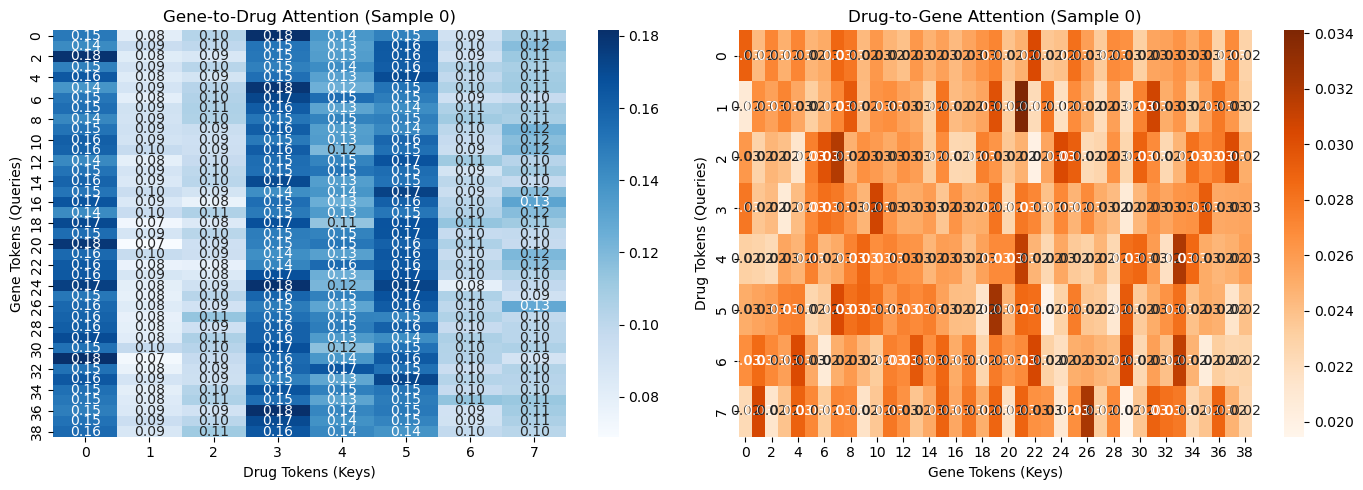

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_weights(model, test_loader, device, sample_idx=0):
    # 1. Ein Batch aus dem Dataloader laden
    b_genes, b_chem, b_y = next(iter(test_loader))
    b_genes = b_genes.to(device)
    b_chem = b_chem.to(device)
    
    # 2. Forward-Pass durchführen (Evaluationsmodus)
    model.eval()
    with torch.no_grad():
        _ = model(b_genes, b_chem)
        
    # 3. Attention Weights aus dem Modell extrahieren
    # Shape: (Batch_Size, Num_Query_Tokens, Num_Key_Tokens)
    attn_dict = model.last_attn_weights
    gene_to_drug_attn = attn_dict["gene_to_drug"][sample_idx]
    drug_to_gene_attn = attn_dict["drug_to_gene"][sample_idx]
    
    # 4. Heatmaps generieren
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gene-to-Drug (Query: Gene Tokens, Key: Drug Tokens)
    sns.heatmap(gene_to_drug_attn, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Gene-to-Drug Attention (Sample {sample_idx})")
    axes[0].set_xlabel("Drug Tokens (Keys)")
    axes[0].set_ylabel("Gene Tokens (Queries)")
    
    # Drug-to-Gene (Query: Drug Tokens, Key: Gene Tokens)
    sns.heatmap(drug_to_gene_attn, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1])
    axes[1].set_title(f"Drug-to-Gene Attention (Sample {sample_idx})")
    axes[1].set_xlabel("Gene Tokens (Keys)")
    axes[1].set_ylabel("Drug Tokens (Queries)")
    
    plt.tight_layout()
    plt.show()

plot_attention_weights(model, test_loader, device, sample_idx=0)

Gene-to-drug: 
- Attention hardly varies among the different gene tokens (rows), but instead exhibits a vertical striped pattern. 
- seems like the model always prioritizes the same chemical features, regardless of the genomic profile.

Drug-to-gene:
- focus on token 1 and 3
- The values fall within a very narrow range between 0.1 and 0.15, and are thus close to the uniform distribution of 0.125

Analysierte Samples im Testset: 13674
Mittlere Korrelation zwischen Samples: 0.5769
Maximale Standardabweichung (Gene-to-Drug): 0.0603
Maximale Standardabweichung (Drug-to-Gene): 0.0040


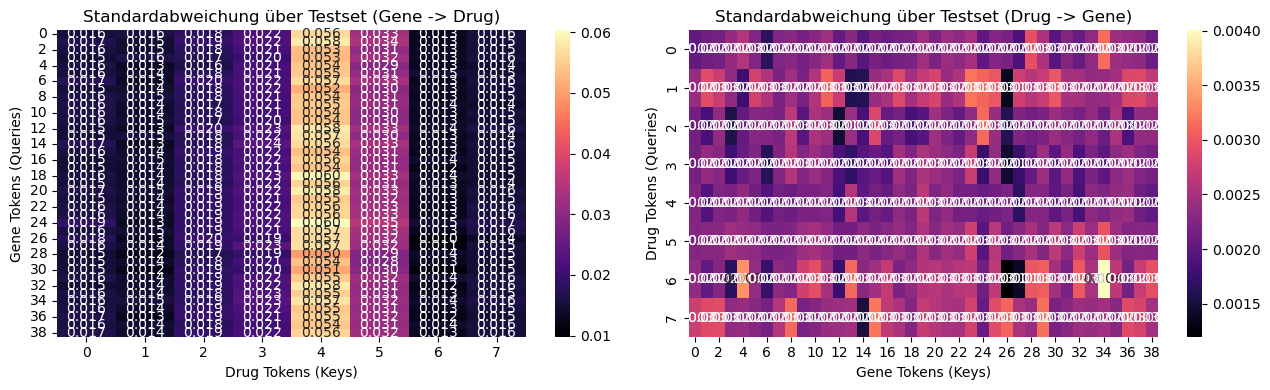

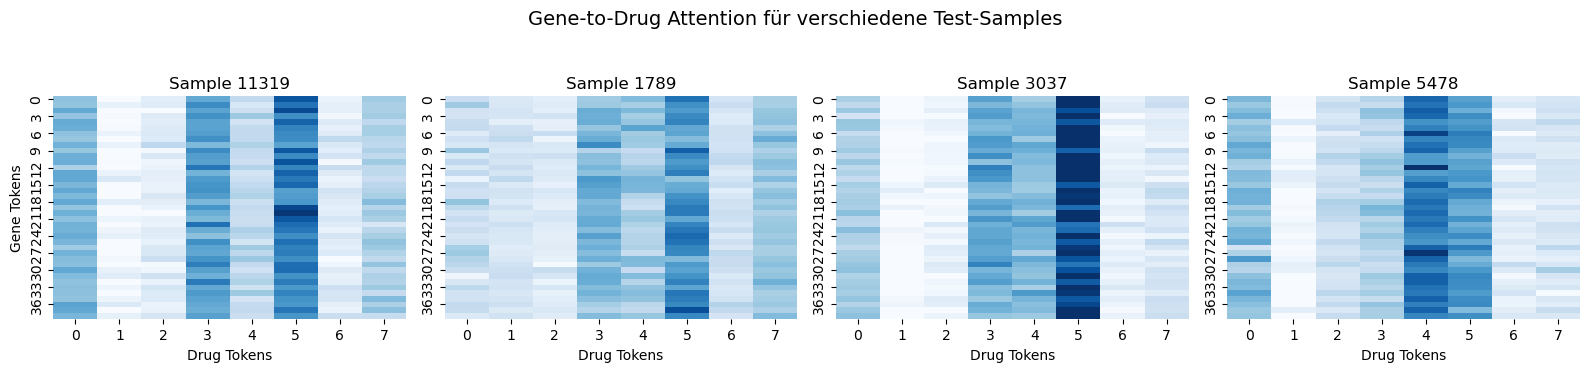

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

def evaluate_attention_diversity(model, test_loader, device, num_samples_to_plot=4):
    model.eval()
    all_gene_to_drug = []
    all_drug_to_gene = []

    # 1. Attention-Gewichte über das gesamte Testset einsammeln
    with torch.no_grad():
        for b_genes, b_chem, _ in test_loader:
            b_genes, b_chem = b_genes.to(device), b_chem.to(device)
            _ = model(b_genes, b_chem)
            
            all_gene_to_drug.append(model.last_attn_weights["gene_to_drug"])
            all_drug_to_gene.append(model.last_attn_weights["drug_to_gene"])

    # Shape: (N_total_samples, Num_Query_Tokens, Num_Key_Tokens)
    g2d = np.concatenate(all_gene_to_drug, axis=0)
    d2g = np.concatenate(all_drug_to_gene, axis=0)

    print(f"Analysierte Samples im Testset: {len(g2d)}")

    # 2. Statistische Auswertung: Standardabweichung über alle Samples
    std_g2d = np.std(g2d, axis=0)
    std_d2g = np.std(d2g, axis=0)

    # Paarweise Korrelation zwischen verschiedenen Samples berechnen
    # Flache Vektoren pro Sample für Gene-to-Drug:
    flat_g2d = g2d.reshape(len(g2d), -1)
    sample_corr = np.corrcoef(flat_g2d[:100]) # Erste 100 Samples
    avg_corr = np.mean(sample_corr[np.triu_indices_from(sample_corr, k=1)])

    print(f"Mittlere Korrelation zwischen Samples: {avg_corr:.4f}")
    print(f"Maximale Standardabweichung (Gene-to-Drug): {std_g2d.max():.4f}")
    print(f"Maximale Standardabweichung (Drug-to-Gene): {std_d2g.max():.4f}")

    # 3. Heatmap der Varianz (Wo verändert sich überhaupt etwas?)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.heatmap(std_g2d, annot=True, fmt=".3f", cmap="magma", ax=axes[0])
    axes[0].set_title("Standardabweichung über Testset (Gene -> Drug)")
    axes[0].set_xlabel("Drug Tokens (Keys)")
    axes[0].set_ylabel("Gene Tokens (Queries)")

    sns.heatmap(std_d2g, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
    axes[1].set_title("Standardabweichung über Testset (Drug -> Gene)")
    axes[1].set_xlabel("Gene Tokens (Keys)")
    axes[1].set_ylabel("Drug Tokens (Queries)")
    plt.tight_layout()
    plt.show()

    # 4. Direkter visueller Vergleich von N zufälligen Beispielen (Gene-to-Drug)
    fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 3.5))
    indices = np.random.choice(len(g2d), size=num_samples_to_plot, replace=False)

    for i, idx in enumerate(indices):
        sns.heatmap(g2d[idx], annot=False, cmap="Blues", ax=axes[i], cbar=False, vmin=0.08, vmax=0.22)
        axes[i].set_title(f"Sample {idx}")
        axes[i].set_xlabel("Drug Tokens")
        if i == 0:
            axes[i].set_ylabel("Gene Tokens")

    plt.suptitle("Gene-to-Drug Attention für verschiedene Test-Samples", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

# Aufruf
evaluate_attention_diversity(model, test_loader, device)

-> attention collapse would mean correlation~1 and standard deviation~0 \
so no attention collapse \
drug-to-gene shows homogeneity, means model couldn't use drug for more information about genes

## Overlap between drugs with structural similarity (global) and functional groups (local)

A. 2D Density & Correlation Analysis (Scatter / Hexbin Plot): Plot $S_{\text{struct}}$ on the X-axis and $S_{\text{FG}}$ on the Y-axis for all active ingredient pairs. Since there are $N \times (N-1) / 2$ pairs, use a hexbin or KDE plot: Calculate the Spearman rank correlation $r_s$ between the two matrices (or perform a Mantel test).

B. Quadrant Analysis (Identification of Scaffold Hops) Set thresholds (e.g., $S_{\text{struct}} \ge 0{,}5$ and $S_{\text{FG}} \ge 0{,}7$) and divide the pairs into four quadrants: High Structure + High FG: Classic chemical analogs/series. Low Structure + High FG (Scaffold Hops): Compounds with completely different scaffolds but identical functional groups. Particularly biologically relevant for your master’s thesis, as they often bind to similar targets. High Structure + Low FG: Structurally related molecules in which key groups have been substituted (potential activity cliffs).

C. $k$-NN Jaccard Overlap (Local Neighborhoods) Determine the top $k$ most similar partners for each molecule based on structure ($N_{\text{struct}}^{(k)}$) and based on functional groups ($N_{\text{FG}}^{(k)}$). $$\text{Overlap}(m) = \frac{\vert{}N_{\text{struct}}^{(k)}(m) \cap N_{\text{FG}}^{(k)}(m)\vert{}}{\vert{}N_{\text{struct}}^{(k)} (m) \cup N_{\text{FG}}^{(k)}(m)\vert{}}$$A low average overlap indicates that functional groups span different similarity spaces than 2D fingerprints.

In statistics, Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from −1 to 1 that indicates how strongly two sets of ranks are correlated. It is used in situations where the ranking of a dataset is important, for instance in sports. If a statistician wanted to know whether people who are high ranking in sprinting are also high ranking in long-distance running, they would use a Spearman rank correlation coefficient.

[13:19:49] WARNING: not removing hydrogen atom without neighbors
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganGenerator
[13:19:49] DEPRECATION WARNING: please use MorganG

Spearman-Korrelation: 0.6735 (p = 0.00e+00)


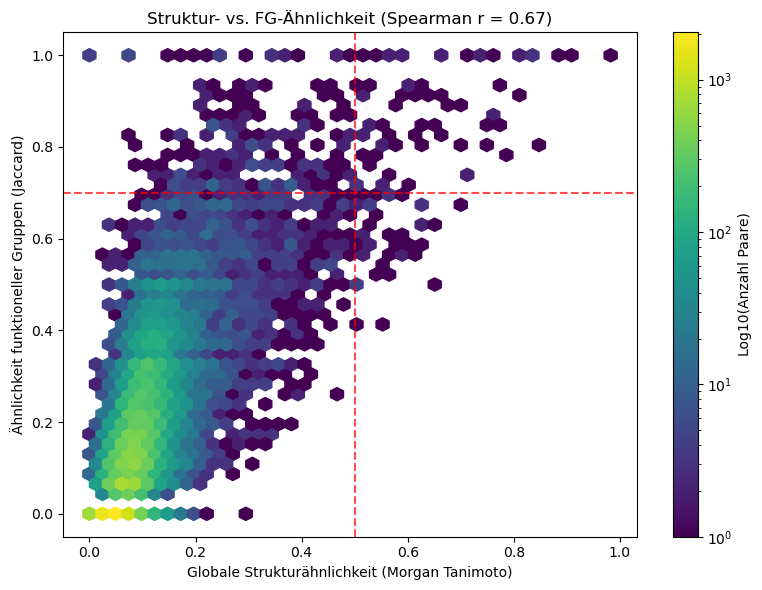

Gefundene Scaffold-Hop-Kandidatenpaare: 60


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Fragments

# Load SMILES and unique molecules
unique_drugs = df.drop_duplicates(subset=['DRUG_ID']).copy()
smiles_list = unique_drugs['SMILES'].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# Calculate structural similarity (Morgan Fingerprints -> Tanimoto)
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in mols]
n_mols = len(mols)

struct_sim_matrix = np.zeros((n_mols, n_mols))
for i in range(n_mols):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    struct_sim_matrix[i] = sims

# Calculate the similarity of functional groups (Jaccard on RDKit fragments)
frag_funcs = [func for name, func in Fragments.__dict__.items() if name.startswith('fr_')]
frag_counts = np.array([[func(m) > 0 for func in frag_funcs] for m in mols], dtype=bool)

# Jaccard Distance (1 – Jaccard Similarity)
fg_dist_matrix = squareform(pdist(frag_counts, metric='jaccard'))
fg_sim_matrix = 1.0 - fg_dist_matrix
np.fill_diagonal(fg_sim_matrix, 1.0)

# Extract the upper triangular matrix (only unique pairs where i < j)
triu_idx = np.triu_indices(n_mols, k=1)
s_struct = struct_sim_matrix[triu_idx]
s_fg = fg_sim_matrix[triu_idx]

# Calculate Correlation
corr, p_val = spearmanr(s_struct, s_fg)
print(f"Spearman Correlation: {corr:.4f} (p = {p_val:.2e})")

# Visualization & Quadrant Analysis
plt.figure(figsize=(8, 6))
hb = plt.hexbin(s_struct, s_fg, gridsize=40, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(hb, label='Log10(Anzahl Paare)')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)
plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.7)

plt.xlabel("Global Structural Similarity (Morgan Tanimoto)")
plt.ylabel("Functional Group Similarity (Jaccard)")
plt.title(f"Structural- vs. FG-Similarity (Spearman r = {corr:.2f})")
plt.tight_layout()
plt.show()

# Filter scaffold hops (low structural similarity but identical functional groups)
scaffold_hops = np.where((s_struct < 0.3) & (s_fg > 0.8))[0]
print(f"Scaffold-hop candidate pairs found: {len(scaffold_hops)}")

In [ ]:
from rdkit.Chem import Draw

# Indizes der 60 Paare auflösen
hop_pairs = [(triu_idx[0][i], triu_idx[1][i]) for i in scaffold_hops]

# Top-3 Paare anzeigen
display_mols = []
legends = []

for idx1, idx2 in hop_pairs[:3]:
    d1 = unique_drugs.iloc[idx1]
    d2 = unique_drugs.iloc[idx2]
    
    display_mols.extend([mols[idx1], mols[idx2]])
    legends.extend([
        f"{d1['DRUG_NAME']} (ID:{d1['DRUG_ID']})",
        f"{d2['DRUG_NAME']} (ID:{d2['DRUG_ID']})"
    ])

img = Draw.MolsToGridImage(display_mols, molsPerRow=2, subImgSize=(300, 200), legends=legends)
img.save("scaffold_hops_examples.png")

### Min-Max Scaler for target value

In [5]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
import matplotlib.pyplot as plt

target = 'LN_IC50'
y_raw = df[target].values.astype('float32')

y_scaler_minmax = MinMaxScaler(feature_range=(0.05, 0.95))
y_scaled_minmax = y_scaler_minmax.fit_transform(y_raw.reshape(-1, 1)).flatten().astype('float32')

y_scaler_robust = RobustScaler()
y_scaled_robust = y_scaler_robust.fit_transform(y_raw.reshape(-1, 1)).flatten().astype('float32')

y_scaler_standard = StandardScaler()
y_scaled_standard = y_scaler_standard.fit_transform(y_raw.reshape(-1, 1)).flatten().astype('float32')

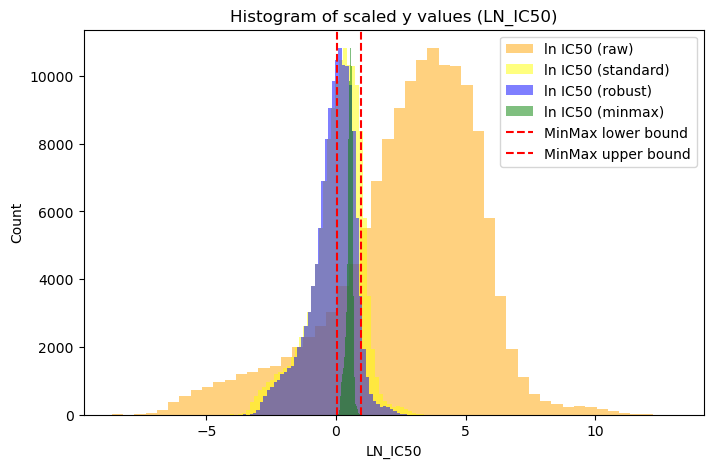

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(y_raw, bins=50, alpha=0.5, label='ln IC50 (raw)', color='orange')
plt.hist(y_scaled_standard, bins=50, alpha=0.5, label='ln IC50 (standard)', color='yellow')
plt.hist(y_scaled_robust, bins=50, alpha=0.5, label='ln IC50 (robust)', color='blue')

plt.hist(y_scaled_minmax, bins=50, alpha=0.5, label='ln IC50 (minmax)', color='green')
plt.axvline(x=0.05, color='red', linestyle='--', label='MinMax lower bound')
plt.axvline(x=0.95, color='red', linestyle='--', label='MinMax upper bound')
plt.xlabel('LN_IC50')
plt.ylabel('Count')
plt.title('Histogram of scaled y values (LN_IC50)')
plt.legend()
plt.show()